In [1]:
import numpy as np
from full_degp.degp import degp
import matplotlib.pyplot as plt

print("Modules imported successfully.")

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Modules imported successfully.


In [2]:
X_train = np.array([[0.0], [0.5], [1.0]])
y_func = np.sin(X_train)
y_deriv1 = np.cos(X_train)
y_train = [y_func, y_deriv1]

print("X_train:", X_train)
print("y_train:", y_train)

X_train: [[0. ]
 [0.5]
 [1. ]]
y_train: [array([[0.        ],
       [0.47942554],
       [0.84147098]]), array([[1.        ],
       [0.87758256],
       [0.54030231]])]


In [3]:
der_indices = [[[[1, 1]]]]
print("der_indices:", der_indices)

der_indices: [[[[1, 1]]]]


In [4]:
model = degp(X_train, y_train, n_order=1, n_bases=1,
             der_indices=der_indices, normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("DEGP model initialized.")

DEGP model initialized.


In [5]:
params =  model.optimize_hyperparameters(
     optimizer='jade',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = None,
     debug = False
     )
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [ -0.77526449   0.78795948 -16.        ]


In [6]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)
y_func_pred = y_train_pred[:len(X_train)]
y_deriv_pred = y_train_pred[len(X_train):]

abs_error_func = np.abs(y_func_pred.flatten() - y_func.flatten())
abs_error_deriv = np.abs(y_deriv_pred.flatten() - y_deriv1.flatten())

print("Absolute error (function) at training points:", abs_error_func)
print("Absolute error (derivative) at training points:", abs_error_deriv)

Absolute error (function) at training points: [2.37304620e-12 2.03725925e-13 2.88657986e-13]
Absolute error (derivative) at training points: [7.55173701e-13 1.33892897e-13 4.36872760e-13]


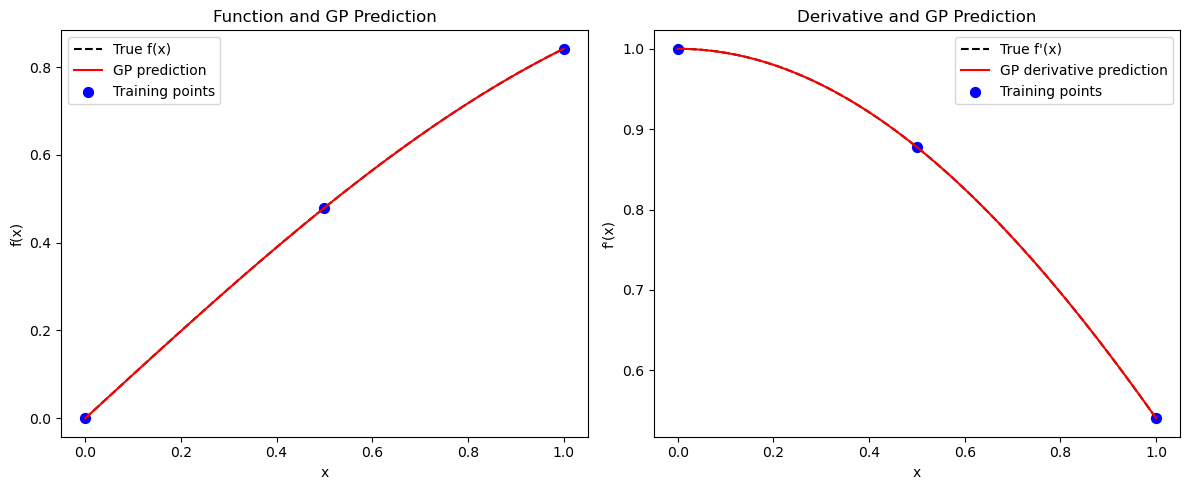

In [7]:
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)

y_func_test = y_test_pred[:len(X_test)]
y_deriv_test = y_test_pred[len(X_test):]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(X_test, np.sin(X_test), 'k--', label='True f(x)')
plt.plot(X_test, y_func_test, 'r-', label='GP prediction')
plt.scatter(X_train, y_func, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function and GP Prediction')
plt.legend()

plt.subplot(1,2,2)
plt.plot(X_test, np.cos(X_test), 'k--', label="True f'(x)")
plt.plot(X_test, y_deriv_test, 'r-', label='GP derivative prediction')
plt.scatter(X_train, y_deriv1, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('Derivative and GP Prediction')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
X_train = np.array([[0.0], [0.5], [1.0]])
y_func = np.sin(X_train)
y_deriv1 = np.cos(X_train)
y_deriv2 = -np.sin(X_train)
y_train = [y_func, y_deriv1, y_deriv2]

print("X_train:", X_train)
print("y_train:", y_train)

X_train: [[0. ]
 [0.5]
 [1. ]]
y_train: [array([[0.        ],
       [0.47942554],
       [0.84147098]]), array([[1.        ],
       [0.87758256],
       [0.54030231]]), array([[-0.        ],
       [-0.47942554],
       [-0.84147098]])]


In [9]:
der_indices = [[[[1, 1]], [[1, 2]]]]
print("der_indices:", der_indices)

der_indices: [[[[1, 1]], [[1, 2]]]]


In [10]:
model = degp(X_train, y_train, n_order=2, n_bases=1,
             der_indices=der_indices, normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("DEGP model (2nd order) initialized.")

DEGP model (2nd order) initialized.


In [11]:
params = model.optimize_hyperparameters(
     optimizer='jade',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = None,
     debug = True
     )
print("Optimized hyperparameters:", params)

Gen 1: best f=-15.111187298441267
Stopping: Objective improvement < 1e-08 at generation 1
Optimized hyperparameters: [ -0.86992927   1.16196008 -15.95618943]


In [12]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

n_train = len(X_train)
y_func_pred = y_train_pred[:n_train]
y_deriv1_pred = y_train_pred[n_train:2*n_train]
y_deriv2_pred = y_train_pred[2*n_train:]

abs_error_func = np.abs(y_func_pred.flatten() - y_func.flatten())
abs_error_deriv1 = np.abs(y_deriv1_pred.flatten() - y_deriv1.flatten())
abs_error_deriv2 = np.abs(y_deriv2_pred.flatten() - y_deriv2.flatten())

print("Absolute error (function) at training points:", abs_error_func)
print("Absolute error (1st derivative) at training points:", abs_error_deriv1)
print("Absolute error (2nd derivative) at training points:", abs_error_deriv2)

Absolute error (function) at training points: [1.21055548e-08 3.90703853e-09 1.13703564e-08]
Absolute error (1st derivative) at training points: [1.81979098e-10 4.66951033e-10 1.70847481e-09]
Absolute error (2nd derivative) at training points: [3.83662207e-10 5.00196162e-10 7.81897214e-10]


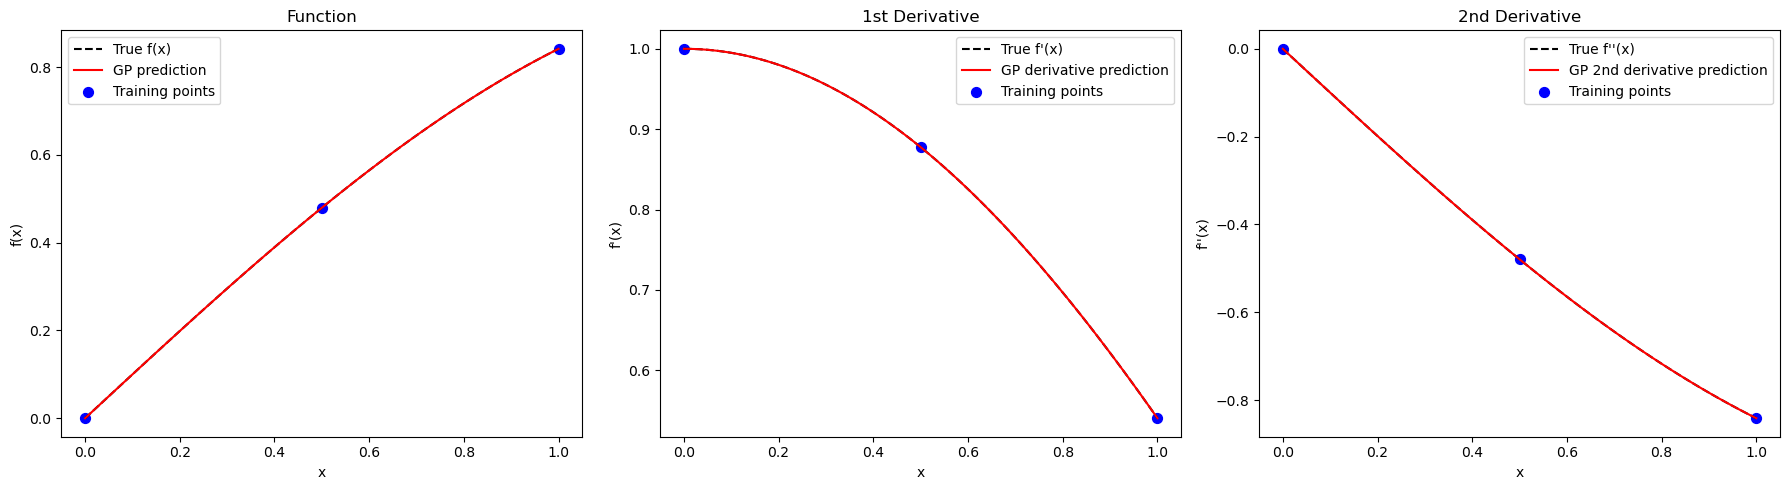

In [13]:
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)

n_test = len(X_test)
y_func_test = y_test_pred[:n_test]
y_deriv1_test = y_test_pred[n_test:2*n_test]
y_deriv2_test = y_test_pred[2*n_test:]

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(X_test, np.sin(X_test), 'k--', label='True f(x)')
plt.plot(X_test, y_func_test, 'r-', label='GP prediction')
plt.scatter(X_train, y_func, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function')
plt.legend()

plt.subplot(1,3,2)
plt.plot(X_test, np.cos(X_test), 'k--', label="True f'(x)")
plt.plot(X_test, y_deriv1_test, 'r-', label='GP derivative prediction')
plt.scatter(X_train, y_deriv1, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('1st Derivative')
plt.legend()

plt.subplot(1,3,3)
plt.plot(X_test, -np.sin(X_test), 'k--', label="True f''(x)")
plt.plot(X_test, y_deriv2_test, 'r-', label='GP 2nd derivative prediction')
plt.scatter(X_train, y_deriv2, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel("f''(x)")
plt.title('2nd Derivative')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from full_degp.degp import degp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Modules imported successfully for 2D example.")

Modules imported successfully for 2D example.


In [15]:
X1 = np.array([0.0, 0.5, 1.0])
X2 = np.array([0.0, 0.5, 1.0])
X1_grid, X2_grid = np.meshgrid(X1, X2)
X_train = np.column_stack([X1_grid.flatten(), X2_grid.flatten()])

y_func = np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_x = np.cos(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_y = -np.sin(X_train[:,0]) * np.sin(X_train[:,1])
y_train = [y_func.reshape(-1,1), y_deriv_x.reshape(-1,1), y_deriv_y.reshape(-1,1)]

print("X_train shape:", X_train.shape)
print("y_train shapes:", [v.shape for v in y_train])

X_train shape: (9, 2)
y_train shapes: [(9, 1), (9, 1), (9, 1)]


In [16]:
der_indices = [[[[1, 1]], [[2, 1]]]]
print("der_indices:", der_indices)

der_indices: [[[[1, 1]], [[2, 1]]]]


In [17]:
model = degp(X_train, y_train, n_order=1, n_bases=2,
             der_indices=der_indices, normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("2D DEGP model initialized.")

2D DEGP model initialized.


In [18]:
params = model.optimize_hyperparameters(
     optimizer='jade',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = None,
     debug = False
     )
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [-0.2963649  -0.76496067  0.94163577 -9.77032629]


In [19]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

n_train = len(X_train)
y_func_pred = y_train_pred[:n_train]
y_deriv_x_pred = y_train_pred[n_train:2*n_train]
y_deriv_y_pred = y_train_pred[2*n_train:]

print("Predictions at training points (function):", y_func_pred)
print("Predictions at training points (deriv x):", y_deriv_x_pred)
print("Predictions at training points (deriv y):", y_deriv_y_pred)

Predictions at training points (function): [[-3.28170824e-12]
 [ 4.79425539e-01]
 [ 8.41470985e-01]
 [-1.60316205e-12]
 [ 4.20735492e-01]
 [ 7.38460263e-01]
 [-3.14609450e-12]
 [ 2.59034724e-01]
 [ 4.54648713e-01]]
Predictions at training points (deriv x): [[1.        ]
 [0.87758256]
 [0.54030231]
 [0.87758256]
 [0.77015115]
 [0.47415988]
 [0.54030231]
 [0.47415988]
 [0.29192658]]
Predictions at training points (deriv y): [[-2.07655253e-13]
 [-1.66124203e-13]
 [ 1.66124203e-13]
 [ 2.49186304e-13]
 [-2.29848847e-01]
 [-4.03422680e-01]
 [ 2.49186304e-13]
 [-4.03422680e-01]
 [-7.08073418e-01]]


In [20]:
abs_error_func = np.abs(y_func_pred.flatten() - y_func)
abs_error_dx = np.abs(y_deriv_x_pred.flatten() - y_deriv_x)
abs_error_dy = np.abs(y_deriv_y_pred.flatten() - y_deriv_y)

print("Absolute error (function) at training points:", abs_error_func)
print("Absolute error (deriv x) at training points:", abs_error_dx)
print("Absolute error (deriv y) at training points:", abs_error_dy)

Absolute error (function) at training points: [3.28170824e-12 1.20659038e-12 2.56306087e-12 1.60316205e-12
 4.41435777e-12 9.50794998e-13 3.14609450e-12 2.85643731e-12
 2.64660516e-12]
Absolute error (deriv x) at training points: [2.02216022e-12 1.06858966e-12 1.69364522e-12 2.66919820e-12
 2.53530530e-12 2.15699680e-12 6.13842310e-13 5.63005198e-12
 1.57096558e-13]
Absolute error (deriv y) at training points: [2.07655253e-13 1.66124203e-13 1.66124203e-13 2.49186304e-13
 1.55070401e-13 5.27800026e-13 2.49186304e-13 1.95565786e-13
 2.22311058e-12]


In [21]:
x1_test = np.linspace(0, 1, 50)
x2_test = np.linspace(0, 1, 50)
X1_test, X2_test = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([X1_test.flatten(), X2_test.flatten()])

y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)
n_test = len(X_test)

y_func_test = y_test_pred[:n_test].reshape(50,50)
y_deriv_x_test = y_test_pred[n_test:2*n_test].reshape(50,50)
y_deriv_y_test = y_test_pred[2*n_test:].reshape(50,50)

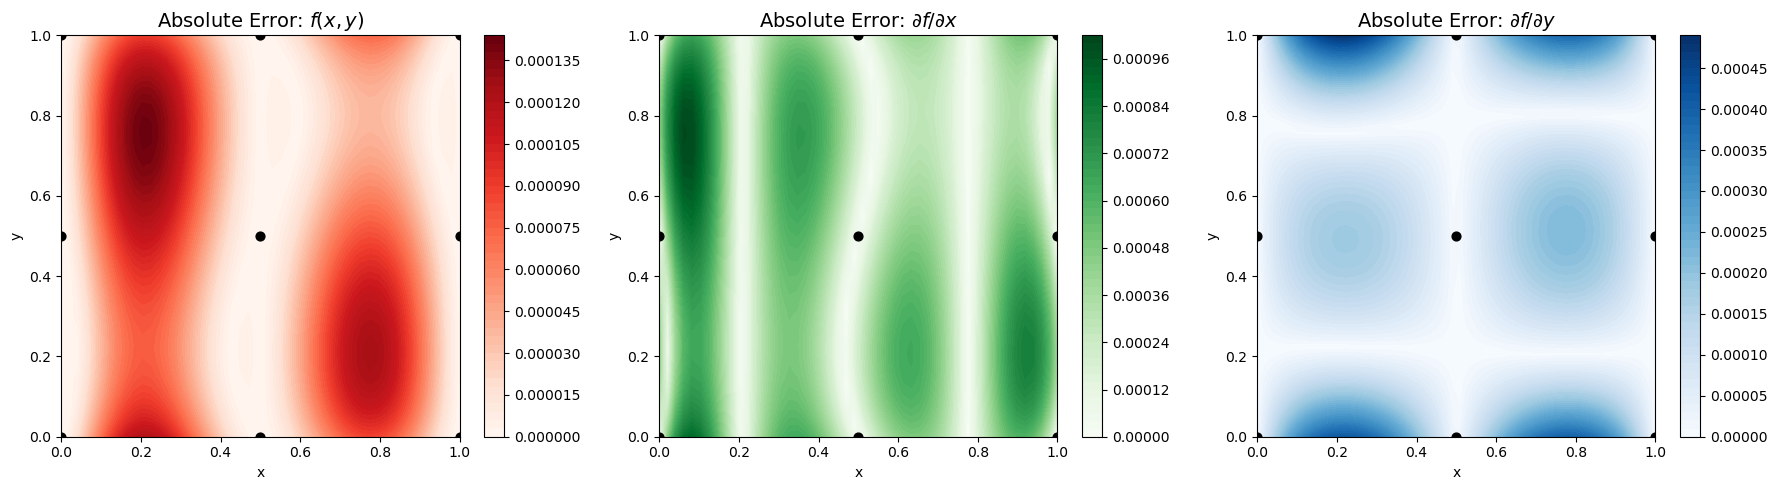

In [22]:
import matplotlib.pyplot as plt

# Compute absolute errors for function and first derivatives
abs_error_func = np.abs(y_func_test - (np.sin(X1_test) * np.cos(X2_test)))
abs_error_dx   = np.abs(y_deriv_x_test - (np.cos(X1_test) * np.cos(X2_test)))
abs_error_dy   = np.abs(y_deriv_y_test - (-np.sin(X1_test) * np.sin(X2_test)))

# Setup figure
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Titles and error arrays
titles = [
   r'Absolute Error: $f(x,y)$',
   r'Absolute Error: $\partial f / \partial x$',
   r'Absolute Error: $\partial f / \partial y$'
]
errors = [abs_error_func, abs_error_dx, abs_error_dy]
cmaps  = ['Reds', 'Greens', 'Blues']

# Plot each contour
for ax, err, title, cmap in zip(axs, errors, titles, cmaps):
   cs = ax.contourf(X1_test, X2_test, err, levels=50, cmap=cmap)
   ax.scatter(X_train[:,0], X_train[:,1], c='k', s=40)
   ax.set_title(title, fontsize=14)
   ax.set_xlabel('x')
   ax.set_ylabel('y')
   fig.colorbar(cs, ax=ax)

plt.tight_layout()
plt.show()

In [23]:
import numpy as np
from full_degp.degp import degp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Modules imported successfully for 2D example with second-order derivatives.")

Modules imported successfully for 2D example with second-order derivatives.


In [24]:
X1 = np.array([0.0, 0.5, 1.0])
X2 = np.array([0.0, 0.5, 1.0])
X1_grid, X2_grid = np.meshgrid(X1, X2)
X_train = np.column_stack([X1_grid.flatten(), X2_grid.flatten()])

# True function and derivatives
y_func = np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_x = np.cos(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_y = -np.sin(X_train[:,0]) * np.sin(X_train[:,1])
y_deriv_xx = -np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_yy = -np.sin(X_train[:,0]) * np.cos(X_train[:,1])

y_train = [
   y_func.reshape(-1,1),
   y_deriv_x.reshape(-1,1),
   y_deriv_y.reshape(-1,1),
   y_deriv_xx.reshape(-1,1),
   y_deriv_yy.reshape(-1,1)
]

print("X_train shape:", X_train.shape)
print("y_train shapes:", [v.shape for v in y_train])

X_train shape: (9, 2)
y_train shapes: [(9, 1), (9, 1), (9, 1), (9, 1), (9, 1)]


In [25]:
der_indices = [
    [ [[1, 1]], [[2, 1]] ],  # first-order derivatives
    [ [[1, 2]], [[2, 2]] ]   # second-order derivatives
]
print("der_indices:", der_indices)

der_indices: [[[[1, 1]], [[2, 1]]], [[[1, 2]], [[2, 2]]]]


In [26]:
model = degp(X_train, y_train, n_order=2, n_bases=2,
             der_indices=der_indices, normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("2D DEGP model with second-order derivatives initialized.")

2D DEGP model with second-order derivatives initialized.


In [27]:
params =   model.optimize_hyperparameters(
     optimizer='jade',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = None,
     debug = False
     )
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [ -0.33435965  -0.13690858   0.24984627 -11.84996009]


In [28]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

n_train = len(X_train)

# First-order
y_func_pred    = y_train_pred[:n_train]
y_deriv_x_pred = y_train_pred[n_train:2*n_train]
y_deriv_y_pred = y_train_pred[2*n_train:3*n_train]

# Second-order main derivatives
y_deriv_xx_pred = y_train_pred[3*n_train:4*n_train]
y_deriv_yy_pred = y_train_pred[4*n_train:5*n_train]

In [29]:
# First-order errors
abs_error_func = np.abs(y_func_pred.flatten() - y_func)
abs_error_dx   = np.abs(y_deriv_x_pred.flatten() - y_deriv_x)
abs_error_dy   = np.abs(y_deriv_y_pred.flatten() - y_deriv_y)

# Second-order main derivative errors
abs_error_dxx  = np.abs(y_deriv_xx_pred.flatten() - y_deriv_xx)
abs_error_dyy  = np.abs(y_deriv_yy_pred.flatten() - y_deriv_yy)

# Print absolute errors
print("Absolute error (function)       :", abs_error_func)
print("Absolute error (derivative x)  :", abs_error_dx)
print("Absolute error (derivative y)  :", abs_error_dy)
print("Absolute error (second x-x)    :", abs_error_dxx)
print("Absolute error (second y-y)    :", abs_error_dyy)

Absolute error (function)       : [8.12583334e-12 2.47690757e-12 9.10604925e-13 1.62120317e-12
 1.47321044e-12 8.93507490e-13 4.12975210e-12 3.84081655e-13
 1.21386234e-12]
Absolute error (derivative x)  : [1.38866696e-12 5.47895063e-13 1.30173650e-12 1.02362563e-13
 3.41948692e-14 6.20392626e-13 2.45681253e-12 5.41178213e-13
 3.73756581e-13]
Absolute error (derivative y)  : [2.27609625e-13 1.63398728e-12 1.48895306e-12 3.40554616e-12
 5.25690602e-14 6.86950496e-13 8.30621014e-13 3.82471832e-13
 9.77218306e-13]
Absolute error (second x-x)    : [1.84564234e-12 3.32023298e-12 4.83502127e-13 8.22978856e-13
 3.74239528e-12 2.27751151e-12 7.39131179e-13 1.31861189e-12
 2.47080134e-12]
Absolute error (second y-y)    : [9.89958921e-12 9.97563143e-12 7.21667170e-12 4.10098590e-12
 3.19511084e-12 2.86548563e-13 8.88864850e-12 6.64490685e-12
 3.40866224e-12]


In [30]:
x1_test = np.linspace(0, 1, 50)
x2_test = np.linspace(0, 1, 50)
X1_test, X2_test = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([X1_test.flatten(), X2_test.flatten()])

y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)
n_test = len(X_test)

y_func_test = y_test_pred[:n_test].reshape(50,50)
y_deriv_x_test = y_test_pred[n_test:2*n_test].reshape(50,50)
y_deriv_y_test = y_test_pred[2*n_test:3*n_test].reshape(50,50)
y_deriv_xx_test = y_test_pred[3*n_test:4*n_test].reshape(50,50)
y_deriv_yy_test = y_test_pred[4*n_test:5*n_test].reshape(50,50)

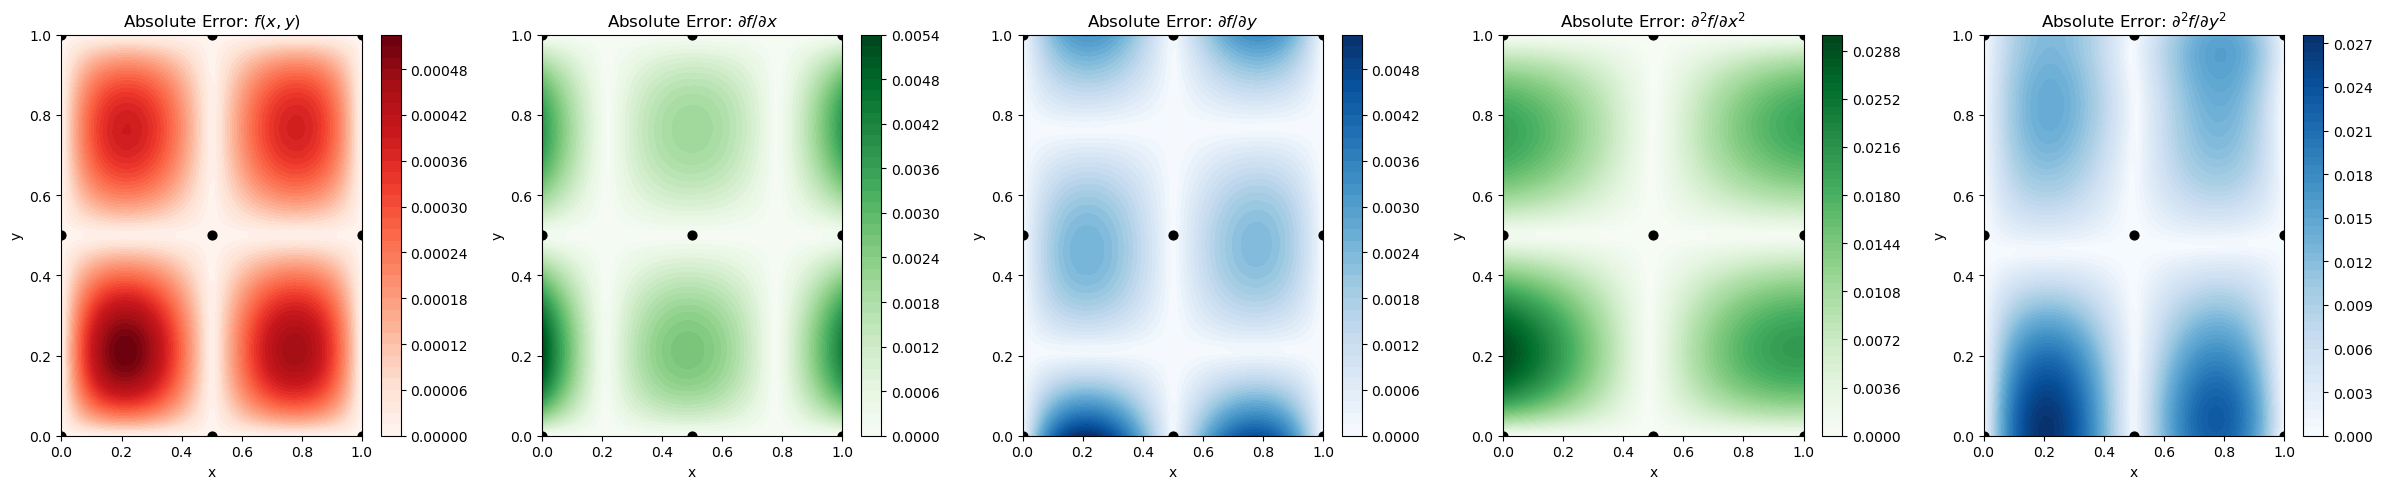

In [31]:
import matplotlib.pyplot as plt

# Compute absolute errors
abs_error_func = np.abs(y_func_test - (np.sin(X1_test) * np.cos(X2_test)))
abs_error_dx   = np.abs(y_deriv_x_test - (np.cos(X1_test) * np.cos(X2_test)))
abs_error_dy   = np.abs(y_deriv_y_test - (-np.sin(X1_test) * np.sin(X2_test)))
abs_error_xx   = np.abs(y_deriv_xx_test - (-np.sin(X1_test) * np.cos(X2_test)))
abs_error_yy   = np.abs(y_deriv_yy_test - (-np.sin(X1_test) * np.cos(X2_test)))

# Setup figure
fig, axs = plt.subplots(1, 5, figsize=(24, 5))

# Titles and errors
titles = [
   r'Absolute Error: $f(x,y)$',
   r'Absolute Error: $\partial f / \partial x$',
   r'Absolute Error: $\partial f / \partial y$',
   r'Absolute Error: $\partial^2 f / \partial x^2$',
   r'Absolute Error: $\partial^2 f / \partial y^2$'
]

errors = [abs_error_func, abs_error_dx, abs_error_dy, abs_error_xx, abs_error_yy]
cmaps  = ['Reds', 'Greens', 'Blues', 'Greens', 'Blues']

# Plot all
for ax, err, title, cmap in zip(axs, errors, titles, cmaps):
   cs = ax.contourf(X1_test, X2_test, err, levels=50, cmap=cmap)
   ax.scatter(X_train[:,0], X_train[:,1], c='k', s=40)
   ax.set_title(title, fontsize=12)
   ax.set_xlabel('x')
   ax.set_ylabel('y')
   fig.colorbar(cs, ax=ax)

plt.tight_layout()
plt.show()